# 🎬 EDA — Multimodal Data: Flickr8k (Text + Image)
**Course:** P4AI-DS (CO3135) — HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k)

**Description:** 8,091 images paired with 5 human-written captions each (40,455 image-caption pairs). 
A true multimodal dataset combining **Visual** (photograph) and **Textual** (caption) modalities for image captioning research.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json as json_lib
import os, re
import warnings
from collections import Counter
from PIL import Image

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk import ngrams as nltk_ngrams

# === LOG SETUP ===
LOG_FILE = 'eda_multimodal_stats.txt'
JSON_FILE = 'eda_multimodal_data.json'
json_data = {}

def log(text, also_print=True):
    with open(LOG_FILE, 'a') as f:
        f.write(text + '\n')
    if also_print:
        print(text)

def save_json():
    with open(JSON_FILE, 'w') as f:
        json_lib.dump(json_data, f, indent=2, default=str)

with open(LOG_FILE, 'w') as f:
    f.write('=' * 70 + '\n')
    f.write('EDA MULTIMODAL STATS — Flickr8k\n')
    f.write('=' * 70 + '\n\n')

STOP_WORDS = set(stopwords.words('english'))
print('✅ Setup complete!')

✅ Setup complete!


### Auto-Download Flickr8k
Requires Kaggle API token at `~/.kaggle/kaggle.json`. 
See [setup guide](https://www.kaggle.com/settings).

In [2]:
DATASET_DIR = 'flickr8k'
IMAGES_DIR = os.path.join(DATASET_DIR, 'Images')
CAPTIONS_FILE = os.path.join(DATASET_DIR, 'captions.txt')

if os.path.exists(CAPTIONS_FILE) and os.path.exists(IMAGES_DIR):
    print('✅ Dataset already exists! Skipping download.')
else:
    print('📥 Downloading Flickr8k from Kaggle...')
    os.makedirs(DATASET_DIR, exist_ok=True)
    try:
        import kaggle
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files('adityajn105/flickr8k', path=DATASET_DIR, unzip=True)
        print('✅ Downloaded via Kaggle API!')
    except Exception as e:
        print(f'⚠️ Kaggle API failed: {e}')
        print('Please download manually from https://www.kaggle.com/datasets/adityajn105/flickr8k')

# Load captions
df = pd.read_csv(CAPTIONS_FILE)
image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f'✅ Loaded {len(df)} caption rows, {len(image_files)} image files')

✅ Dataset already exists! Skipping download.
✅ Loaded 40455 caption rows, 8091 image files


## 1. 📚 Analysis Methodology

| Analysis Type | Purpose | Key Metrics |
|---|---|---|
| **Missing Modalities** | Check for unpaired data | % complete pairs, corrupted files |
| **Unimodal — Visual** | Image properties | Dimensions, aspect ratio, brightness, color channels |
| **Unimodal — Text** | Caption properties | Word/char count, vocabulary, n-grams |
| **Cross-Modal Alignment** | Text-Image relationship | Caption similarity, length vs image complexity |
| **Target/Label Distribution** | Label balance | First-word patterns, subject frequency |

**💡 Key Principle:** Multimodal EDA must assess each modality independently AND their alignment together.

## 2. 📊 Dataset Overview

In [3]:
log('=== SECTION 2: DATASET OVERVIEW ===')

n_total_pairs = len(df)
n_unique_images = df['image'].nunique()
n_image_files = len(image_files)
captions_per_image = df.groupby('image').size()
n_modalities = 2  # Text + Image

log(f'Total image-caption pairs: {n_total_pairs}')
log(f'Unique images (in captions): {n_unique_images}')
log(f'Image files on disk: {n_image_files}')
log(f'Captions per image: min={captions_per_image.min()}, max={captions_per_image.max()}, mean={captions_per_image.mean():.1f}')
log(f'Number of modalities: {n_modalities} (Image + Text)')
log(f'Image format: JPEG (variable resolution)')
log(f'Text format: English captions (UTF-8)')

# Average file size
sample_sizes = [os.path.getsize(os.path.join(IMAGES_DIR, f)) / 1024 
                for f in image_files[:500]]
avg_file_size_kb = np.mean(sample_sizes)
log(f'Avg image file size: {avg_file_size_kb:.0f} KB')
log(f'Estimated total storage: {avg_file_size_kb * n_image_files / 1024:.0f} MB')

# Feature descriptions
feature_desc = [
    {'name': 'image', 'type': 'Filename', 'description': 'JPEG image filename (visual modality)'},
    {'name': 'caption', 'type': 'Text', 'description': 'Human-written description of the image (textual modality)'},
]

# Missing values
missing = df.isnull().sum()
log(f'\nMissing values in DataFrame: {missing.sum()}')

json_data['dataset_overview'] = {
    'n_total_pairs': n_total_pairs,
    'n_unique_images': n_unique_images,
    'n_image_files': n_image_files,
    'n_modalities': n_modalities,
    'modalities': ['Image (JPEG)', 'Text (Caption)'],
    'captions_per_image': {'min': int(captions_per_image.min()), 'max': int(captions_per_image.max()), 
                           'mean': round(float(captions_per_image.mean()), 1)},
    'avg_file_size_kb': round(avg_file_size_kb, 1),
    'feature_descriptions': feature_desc,
    'missing_values': {str(k): int(v) for k, v in missing.items()}
}
save_json()

df.head()

=== SECTION 2: DATASET OVERVIEW ===
Total image-caption pairs: 40455
Unique images (in captions): 8091
Image files on disk: 8091
Captions per image: min=5, max=5, mean=5.0
Number of modalities: 2 (Image + Text)
Image format: JPEG (variable resolution)
Text format: English captions (UTF-8)
Avg image file size: 135 KB
Estimated total storage: 1071 MB

Missing values in DataFrame: 0


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## 3. 🔍 Data Quality & Missing Modalities


=== SECTION 3: DATA QUALITY & MISSING MODALITIES ===
Complete pairs (both image + text): 8091 (100.0%)
Text-only (caption exists, image missing): 0 (0.0%)
Image-only (image exists, no caption): 0

Corrupted image check (sampled 2000):
  Corrupted found: 0 (0.00%)
  Estimated total corrupted: ~0


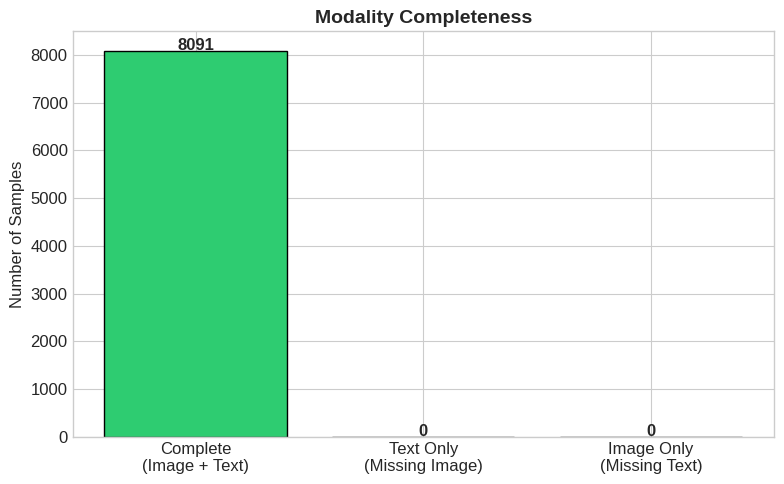

In [4]:
log('\n=== SECTION 3: DATA QUALITY & MISSING MODALITIES ===')

# Check which images in captions actually exist on disk
images_in_captions = set(df['image'].unique())
images_on_disk = set(image_files)

# Missing modality analysis
text_only = images_in_captions - images_on_disk  # have caption but no image
image_only = images_on_disk - images_in_captions  # have image but no caption
complete_pairs = images_in_captions & images_on_disk  # have both

log(f'Complete pairs (both image + text): {len(complete_pairs)} ({len(complete_pairs)/n_unique_images*100:.1f}%)')
log(f'Text-only (caption exists, image missing): {len(text_only)} ({len(text_only)/n_unique_images*100:.1f}%)')
log(f'Image-only (image exists, no caption): {len(image_only)}')

# Check for corrupted images
corrupted_count = 0
corrupted_files = []
np.random.seed(42)
check_files = np.random.choice(image_files, min(2000, len(image_files)), replace=False)

for f in check_files:
    try:
        img = Image.open(os.path.join(IMAGES_DIR, f))
        img.verify()  # verify integrity
    except:
        corrupted_count += 1
        corrupted_files.append(f)

est_corrupted = int(corrupted_count / len(check_files) * n_image_files)
log(f'\nCorrupted image check (sampled {len(check_files)}):')
log(f'  Corrupted found: {corrupted_count} ({corrupted_count/len(check_files)*100:.2f}%)')
log(f'  Estimated total corrupted: ~{est_corrupted}')

json_data['data_quality'] = {
    'complete_pairs': len(complete_pairs),
    'complete_pairs_pct': round(len(complete_pairs)/n_unique_images*100, 1),
    'text_only_missing_image': len(text_only),
    'image_only_missing_caption': len(image_only),
    'corrupted_images_sampled': corrupted_count,
    'corrupted_images_sample_size': len(check_files),
    'corrupted_pct': round(corrupted_count/len(check_files)*100, 2),
    'corrupted_files': corrupted_files
}
save_json()

# --- Chart: Modality completeness ---
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Complete\n(Image + Text)', 'Text Only\n(Missing Image)', 'Image Only\n(Missing Text)']
values = [len(complete_pairs), len(text_only), len(image_only)]
colors = ['#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(labels, values, color=colors, edgecolor='black')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Modality Completeness', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('multimodal_01_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🖼️ Visual Modality Analysis


=== SECTION 4: VISUAL MODALITY ANALYSIS ===
Image dimension stats (2000 sampled):
  Width:  mean=457, min=182, max=500, std=70
  Height: mean=397, min=166, max=500, std=76
  Aspect ratio: mean=1.220, min=0.364, max=3.012
  File size: mean=133 KB, min=29, max=306

Color channel means:
  Red:   117.0
  Green: 113.8
  Blue:  103.2
  Brightness: 111.4


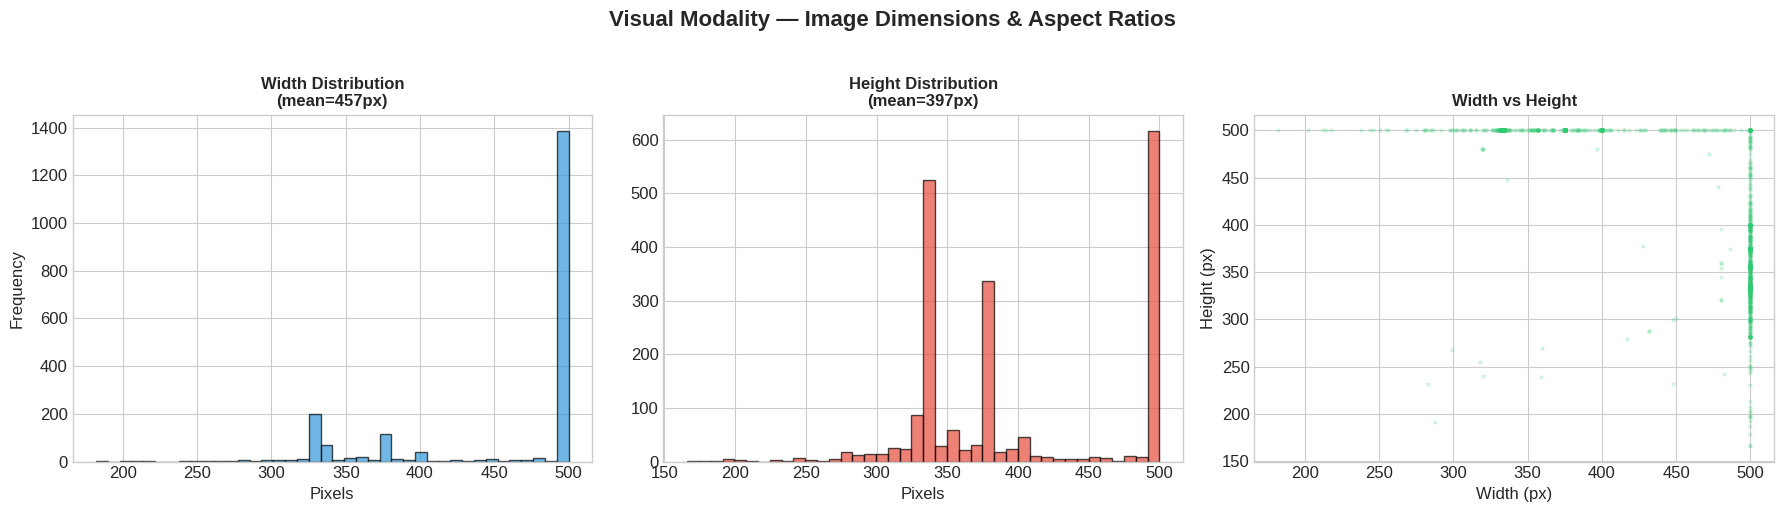

In [5]:
log('\n=== SECTION 4: VISUAL MODALITY ANALYSIS ===')

# Collect image properties
widths, heights, aspects, file_sizes_kb = [], [], [], []
avg_r, avg_g, avg_b, brightness = [], [], [], []

np.random.seed(42)
sample_imgs = np.random.choice(image_files, min(2000, len(image_files)), replace=False)

for f in sample_imgs:
    fpath = os.path.join(IMAGES_DIR, f)
    try:
        img = Image.open(fpath).convert('RGB')
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)
        file_sizes_kb.append(os.path.getsize(fpath) / 1024)
        
        img_arr = np.array(img)
        avg_r.append(float(img_arr[:,:,0].mean()))
        avg_g.append(float(img_arr[:,:,1].mean()))
        avg_b.append(float(img_arr[:,:,2].mean()))
        brightness.append(float(img_arr.mean()))
    except:
        pass

# Log stats
log(f'Image dimension stats ({len(widths)} sampled):')
log(f'  Width:  mean={np.mean(widths):.0f}, min={np.min(widths)}, max={np.max(widths)}, std={np.std(widths):.0f}')
log(f'  Height: mean={np.mean(heights):.0f}, min={np.min(heights)}, max={np.max(heights)}, std={np.std(heights):.0f}')
log(f'  Aspect ratio: mean={np.mean(aspects):.3f}, min={np.min(aspects):.3f}, max={np.max(aspects):.3f}')
log(f'  File size: mean={np.mean(file_sizes_kb):.0f} KB, min={np.min(file_sizes_kb):.0f}, max={np.max(file_sizes_kb):.0f}')
log(f'\nColor channel means:')
log(f'  Red:   {np.mean(avg_r):.1f}')
log(f'  Green: {np.mean(avg_g):.1f}')
log(f'  Blue:  {np.mean(avg_b):.1f}')
log(f'  Brightness: {np.mean(brightness):.1f}')

json_data['visual_modality'] = {
    'sample_size': len(widths),
    'dimensions': {
        'width': {'mean': round(np.mean(widths),0), 'min': int(np.min(widths)), 'max': int(np.max(widths)), 'std': round(np.std(widths),0),
                  'histogram_values': np.histogram(widths, bins=30)[0].tolist(), 'histogram_edges': np.histogram(widths, bins=30)[1].tolist()},
        'height': {'mean': round(np.mean(heights),0), 'min': int(np.min(heights)), 'max': int(np.max(heights)), 'std': round(np.std(heights),0),
                   'histogram_values': np.histogram(heights, bins=30)[0].tolist(), 'histogram_edges': np.histogram(heights, bins=30)[1].tolist()},
        'aspect_ratio': {'mean': round(np.mean(aspects),3), 'min': round(np.min(aspects),3), 'max': round(np.max(aspects),3),
                       'histogram_values': np.histogram(aspects, bins=15)[0].tolist(),
                       'histogram_edges': np.histogram(aspects, bins=15)[1].tolist()}
    },
    'file_size_kb': {'mean': round(np.mean(file_sizes_kb),1), 'min': round(np.min(file_sizes_kb),1), 'max': round(np.max(file_sizes_kb),1),
                      'histogram_values': np.histogram(file_sizes_kb, bins=15)[0].tolist(),
                      'histogram_edges': np.histogram(file_sizes_kb, bins=15)[1].tolist()},
    'color_channels': {
        'red_mean': round(np.mean(avg_r), 1), 'green_mean': round(np.mean(avg_g), 1), 'blue_mean': round(np.mean(avg_b), 1),
        'brightness_mean': round(np.mean(brightness), 1),
        'red_histogram': np.histogram(avg_r, bins=40)[0].tolist(),
        'green_histogram': np.histogram(avg_g, bins=40)[0].tolist(),
        'blue_histogram': np.histogram(avg_b, bins=40)[0].tolist(),
        'brightness_histogram': np.histogram(brightness, bins=40)[0].tolist(),
        'histogram_edges': np.histogram(brightness, bins=40)[1].tolist()
    },
    'width_height_scatter': {'widths': [int(w) for w in widths[:500]], 'heights': [int(h) for h in heights[:500]]}
}
save_json()

# --- Charts: Dimensions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(widths, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Width Distribution\n(mean={np.mean(widths):.0f}px)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Frequency')

axes[1].hist(heights, bins=40, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Height Distribution\n(mean={np.mean(heights):.0f}px)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pixels')

axes[2].scatter(widths, heights, alpha=0.15, s=5, color='#2ecc71')
axes[2].set_title('Width vs Height', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.suptitle('Visual Modality — Image Dimensions & Aspect Ratios', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_02_image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

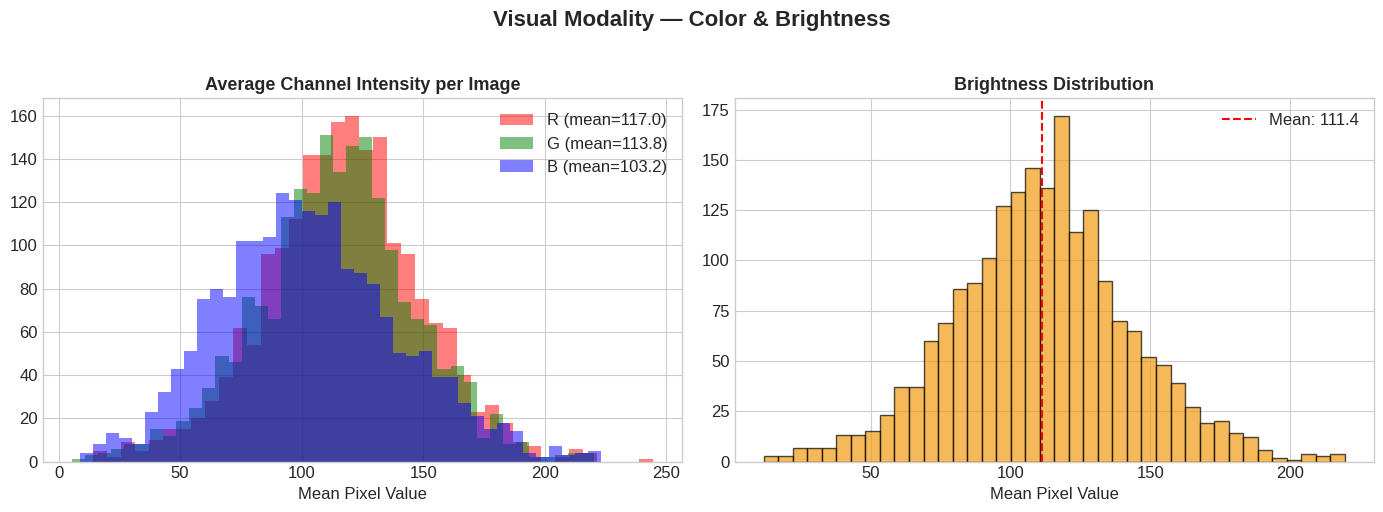

In [6]:
# --- Charts: Color & Brightness ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(avg_r, bins=40, alpha=0.5, color='red', label=f'R (mean={np.mean(avg_r):.1f})')
axes[0].hist(avg_g, bins=40, alpha=0.5, color='green', label=f'G (mean={np.mean(avg_g):.1f})')
axes[0].hist(avg_b, bins=40, alpha=0.5, color='blue', label=f'B (mean={np.mean(avg_b):.1f})')
axes[0].set_title('Average Channel Intensity per Image', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].legend()

axes[1].hist(brightness, bins=40, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(brightness), color='red', linestyle='--', label=f'Mean: {np.mean(brightness):.1f}')
axes[1].set_title('Brightness Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Pixel Value')
axes[1].legend()

plt.suptitle('Visual Modality — Color & Brightness', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_03_color_brightness.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 📝 Textual Modality Analysis


=== SECTION 5: TEXTUAL MODALITY ANALYSIS ===
Caption word count: mean=11.8, median=11.0, min=1, max=38
Caption char count: mean=55.1
Vocabulary size (excl stopwords): 8274
Stopword ratio: 42.4%
Top 10 words: ['dog', 'man', 'two', 'white', 'black', 'boy', 'woman', 'girl', 'wearing', 'people']
Top 5 bigrams: ['white dog', 'brown dog', 'black dog', 'dog running', 'two dogs']
Top 5 trigrams: ['black white dog', 'brown white dog', 'white dog running', 'brown dog running', 'black dog running']


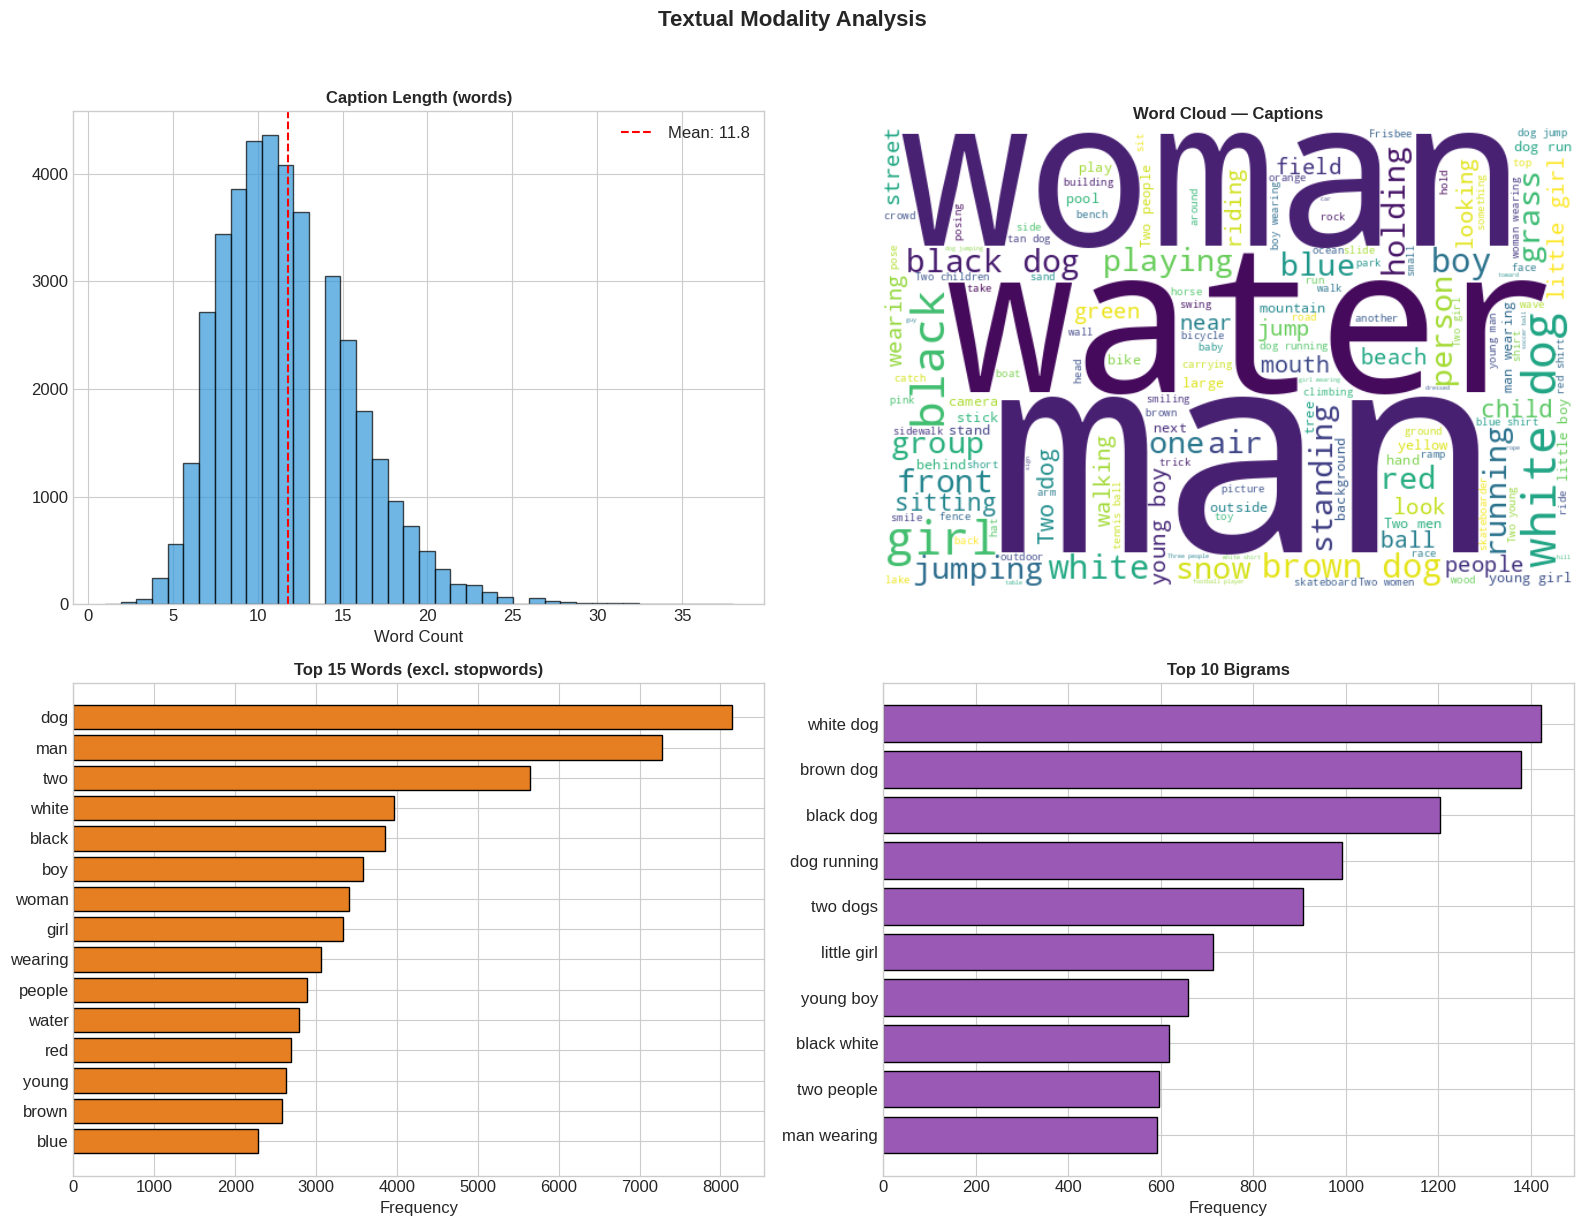

In [7]:
log('\n=== SECTION 5: TEXTUAL MODALITY ANALYSIS ===')

df['caption_word_count'] = df['caption'].apply(lambda x: len(str(x).split()))
df['caption_char_count'] = df['caption'].apply(lambda x: len(str(x)))

# Length stats
text_stats = {
    'word_count': {
        'mean': round(float(df['caption_word_count'].mean()), 1),
        'median': round(float(df['caption_word_count'].median()), 1),
        'std': round(float(df['caption_word_count'].std()), 1),
        'min': int(df['caption_word_count'].min()),
        'max': int(df['caption_word_count'].max()),
        'histogram_values': np.histogram(df['caption_word_count'], bins=40)[0].tolist(),
        'histogram_edges': np.histogram(df['caption_word_count'], bins=40)[1].tolist()
    },
    'char_count': {
        'mean': round(float(df['caption_char_count'].mean()), 1),
        'median': round(float(df['caption_char_count'].median()), 1),
        'min': int(df['caption_char_count'].min()),
        'max': int(df['caption_char_count'].max())
    }
}
log(f'Caption word count: mean={text_stats["word_count"]["mean"]}, median={text_stats["word_count"]["median"]}, '
    f'min={text_stats["word_count"]["min"]}, max={text_stats["word_count"]["max"]}')
log(f'Caption char count: mean={text_stats["char_count"]["mean"]}')

# Lexical analysis
def tokenize_clean(texts, stop_words=STOP_WORDS, min_len=3):
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        words = [w for w in words if w not in stop_words and len(w) >= min_len]
        all_words.extend(words)
    return all_words

clean_words = tokenize_clean(df['caption'])
word_freq = Counter(clean_words)
vocab_size = len(word_freq)
top_30_words = word_freq.most_common(30)

# Stopword ratio
all_raw = []
for c in df['caption']:
    all_raw.extend(re.findall(r'\b[a-z]+\b', str(c).lower()))
stopword_ratio = sum(1 for w in all_raw if w in STOP_WORDS) / len(all_raw) * 100

log(f'Vocabulary size (excl stopwords): {vocab_size}')
log(f'Stopword ratio: {stopword_ratio:.1f}%')
log(f'Top 10 words: {[w for w, _ in top_30_words[:10]]}')

# Bigrams
def get_ngrams(texts, n, top_k=15):
    all_ng = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        words = [w for w in words if w not in STOP_WORDS and len(w) >= 3]
        all_ng.extend(list(nltk_ngrams(words, n)))
    return Counter(all_ng).most_common(top_k)

bigrams = get_ngrams(df['caption'], 2, 15)
trigrams = get_ngrams(df['caption'], 3, 15)

bigram_data = [{'bigram': ' '.join(g), 'count': c} for g, c in bigrams]
trigram_data = [{'trigram': ' '.join(g), 'count': c} for g, c in trigrams]

log(f'Top 5 bigrams: {[d["bigram"] for d in bigram_data[:5]]}')
log(f'Top 5 trigrams: {[d["trigram"] for d in trigram_data[:5]]}')

text_stats['vocab_size'] = vocab_size
text_stats['stopword_ratio_pct'] = round(stopword_ratio, 1)
text_stats['top_30_words'] = [{'word': w, 'count': c} for w, c in top_30_words]
text_stats['bigrams'] = bigram_data
text_stats['trigrams'] = trigram_data
json_data['textual_modality'] = text_stats
save_json()

# --- Charts ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram word count
axes[0,0].hist(df['caption_word_count'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['caption_word_count'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df["caption_word_count"].mean():.1f}')
axes[0,0].set_title('Caption Length (words)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Word Count')
axes[0,0].legend()

# Word Cloud
wc = WordCloud(width=600, height=400, background_color='white', stopwords=STOP_WORDS,
               max_words=150, colormap='viridis', random_state=42)
wc.generate(' '.join(df['caption'].values))
axes[0,1].imshow(wc, interpolation='bilinear')
axes[0,1].axis('off')
axes[0,1].set_title('Word Cloud — Captions', fontsize=12, fontweight='bold')

# Top 15 words
w15, c15 = zip(*top_30_words[:15])
axes[1,0].barh(range(len(w15)), c15, color='#e67e22', edgecolor='black')
axes[1,0].set_yticks(range(len(w15)))
axes[1,0].set_yticklabels(w15)
axes[1,0].set_xlabel('Frequency')
axes[1,0].set_title('Top 15 Words (excl. stopwords)', fontsize=12, fontweight='bold')
axes[1,0].invert_yaxis()

# Top 10 bigrams
bi_labels = [d['bigram'] for d in bigram_data[:10]]
bi_counts = [d['count'] for d in bigram_data[:10]]
axes[1,1].barh(range(len(bi_labels)), bi_counts, color='#9b59b6', edgecolor='black')
axes[1,1].set_yticks(range(len(bi_labels)))
axes[1,1].set_yticklabels(bi_labels)
axes[1,1].set_xlabel('Frequency')
axes[1,1].set_title('Top 10 Bigrams', fontsize=12, fontweight='bold')
axes[1,1].invert_yaxis()

plt.suptitle('Textual Modality Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_04_text_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 🔗 Cross-Modal Analysis


=== SECTION 6: CROSS-MODAL ANALYSIS ===
⏳ Computing caption similarity statistics (~30s)...
Caption similarity (Jaccard):
  Mean: 0.278
  Std:  0.139
  ~28% average word overlap between captions for same image
Correlation (caption length vs similarity): r=-0.075, p=0.0000
Correlation (caption length vs image file size): r=-0.016, p=0.4704


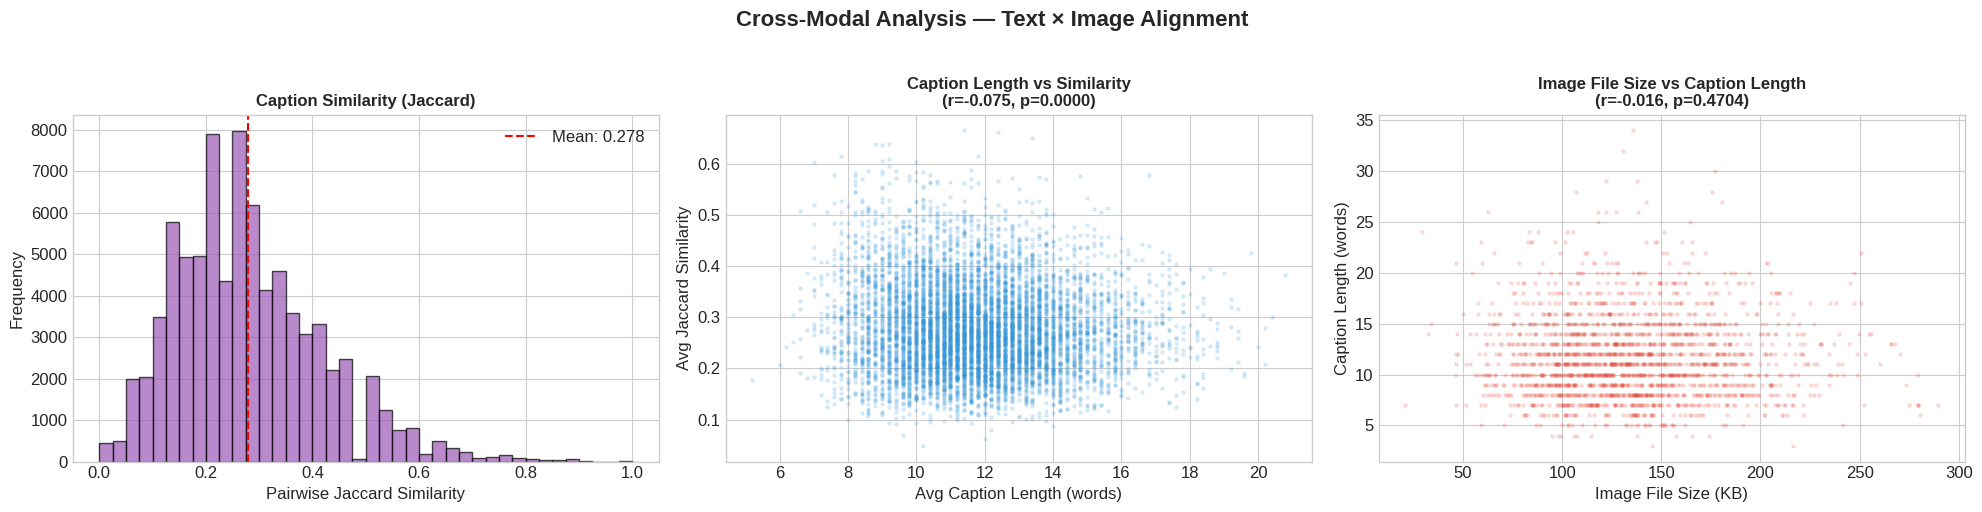

In [8]:
log('\n=== SECTION 6: CROSS-MODAL ANALYSIS ===')

# --- Caption Similarity (Jaccard) ---
from scipy.stats import pearsonr
from itertools import combinations

def jaccard_similarity(caption1, caption2):
    """Compute Jaccard index between two captions (tokenized as sets)"""
    tokens1 = set(str(caption1).lower().split())
    tokens2 = set(str(caption2).lower().split())
    intersection = tokens1 & tokens2
    union = tokens1 | tokens2
    return len(intersection) / len(union) if len(union) > 0 else 0.0

print('⏳ Computing caption similarity statistics (~30s)...')

# Compute all pairwise similarities
all_similarities = []
image_avg_lengths = []
image_avg_similarities = []

unique_images = df['image'].unique()
for image_id in unique_images:
    image_captions = df[df['image'] == image_id]['caption'].tolist()
    
    # Compute pairwise similarities for this image
    image_sims = []
    for cap1, cap2 in combinations(image_captions, 2):
        sim = jaccard_similarity(cap1, cap2)
        all_similarities.append(sim)
        image_sims.append(sim)
    
    # Average caption length for this image
    avg_length = np.mean([len(str(cap).split()) for cap in image_captions])
    image_avg_lengths.append(avg_length)
    
    # Average similarity for this image
    image_avg_similarities.append(np.mean(image_sims) if image_sims else 0.0)

# Overall similarity statistics
similarity_mean = np.mean(all_similarities)
similarity_std = np.std(all_similarities)
similarity_hist_values, similarity_hist_edges = np.histogram(all_similarities, bins=20)

log(f'Caption similarity (Jaccard):')
log(f'  Mean: {similarity_mean:.3f}')
log(f'  Std:  {similarity_std:.3f}')
log(f'  ~{similarity_mean*100:.0f}% average word overlap between captions for same image')

# --- Correlation: Caption Length vs Similarity ---
corr_length_similarity, p_value_length_sim = pearsonr(image_avg_lengths, image_avg_similarities)
log(f'Correlation (caption length vs similarity): r={corr_length_similarity:.3f}, p={p_value_length_sim:.4f}')

# --- Correlation: Caption Length vs Image File Size ---
# Get file sizes for all images
img_file_sizes = {}
for f in image_files:
    img_file_sizes[f] = os.path.getsize(os.path.join(IMAGES_DIR, f)) / 1024

# Sample caption-image pairs
np.random.seed(42)
sampled_pairs = df.sample(n=min(2000, len(df)), random_state=42)
caption_lengths = []
file_sizes = []

for _, row in sampled_pairs.iterrows():
    img_path = os.path.join(IMAGES_DIR, row['image'])
    if os.path.exists(img_path):
        caption_lengths.append(len(str(row['caption']).split()))
        file_sizes.append(os.path.getsize(img_path) / 1024)

corr_length_filesize, p_value_length_size = pearsonr(caption_lengths, file_sizes)
log(f'Correlation (caption length vs image file size): r={corr_length_filesize:.3f}, p={p_value_length_size:.4f}')

# Export to JSON with complete structure
json_data['cross_modal_analysis'] = {
    'caption_similarity': {
        'jaccard': {
            'mean': float(similarity_mean),
            'std': float(similarity_std),
            'histogram_values': similarity_hist_values.tolist(),
            'histogram_edges': similarity_hist_edges.tolist()
        }
    },
    'correlations': {
        'caption_length_vs_similarity': {
            'r': float(corr_length_similarity),
            'p_value': float(p_value_length_sim)
        },
        'caption_length_vs_filesize': {
            'r': float(corr_length_filesize),
            'p_value': float(p_value_length_size)
        }
    },
    'length_size_scatter': {
        'caption_lengths': caption_lengths,
        'file_sizes': file_sizes
    }
}
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Jaccard similarity distribution
axes[0].hist(all_similarities, bins=40, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].axvline(similarity_mean, color='red', linestyle='--', label=f'Mean: {similarity_mean:.3f}')
axes[0].set_title('Caption Similarity (Jaccard)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pairwise Jaccard Similarity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Caption length vs similarity
axes[1].scatter(image_avg_lengths, image_avg_similarities,
                alpha=0.15, s=5, color='#3498db')
axes[1].set_title(f'Caption Length vs Similarity\n(r={corr_length_similarity:.3f}, p={p_value_length_sim:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Caption Length (words)')
axes[1].set_ylabel('Avg Jaccard Similarity')

# Caption length vs image file size
axes[2].scatter(file_sizes, caption_lengths,
                alpha=0.15, s=5, color='#e74c3c')
axes[2].set_title(f'Image File Size vs Caption Length\n(r={corr_length_filesize:.3f}, p={p_value_length_size:.4f})',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Image File Size (KB)')
axes[2].set_ylabel('Caption Length (words)')

plt.suptitle('Cross-Modal Analysis — Text × Image Alignment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_05_cross_modal.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🎯 Target/Label Distribution


=== SECTION 7: TARGET/LABEL DISTRIBUTION ===
First-word distribution (top 10):
  "a": 24704 (61.1%)
  "two": 4727 (11.7%)
  "the": 3121 (7.7%)
  "three": 1168 (2.9%)
  "an": 533 (1.3%)
  "people": 460 (1.1%)
  "man": 455 (1.1%)
  "four": 389 (1.0%)
  "there": 272 (0.7%)
  "one": 240 (0.6%)

Subject/Object frequency:
  dog: 8136
  man: 7265
  boy: 3581
  woman: 3402
  girl: 3328
  people: 2883
  water: 2783
  ball: 1779
  grass: 1622
  child: 1545

Subject imbalance ratio: 35.1x (dog vs horse)


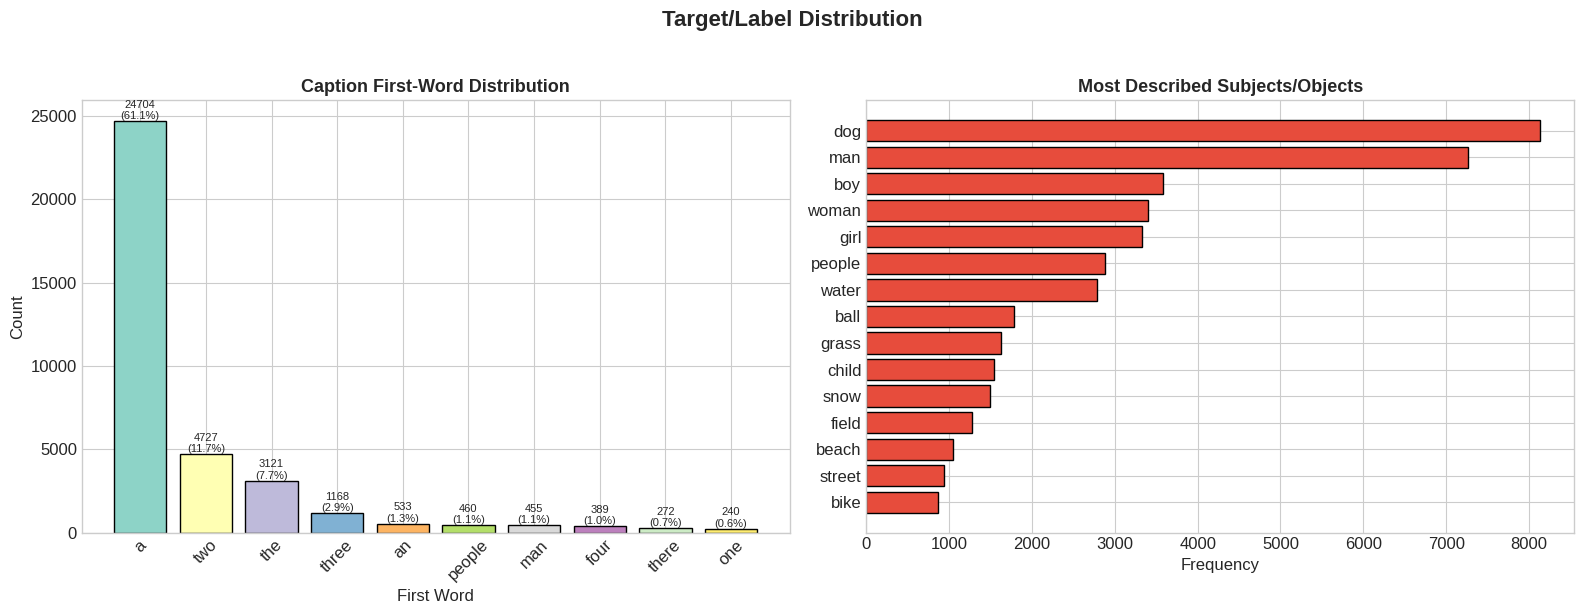

In [9]:
log('\n=== SECTION 7: TARGET/LABEL DISTRIBUTION ===')

# Flickr8k doesn't have explicit labels, so we analyze:
# 1. First-word patterns (implicit "label" of caption style)
# 2. Subject/object frequency (implicit content labels)

df['first_word'] = df['caption'].apply(lambda x: str(x).split()[0].lower() if len(str(x).split()) > 0 else '')
first_word_counts = df['first_word'].value_counts().head(10)

log('First-word distribution (top 10):')
first_word_data = []
for word, count in first_word_counts.items():
    pct = round(count / len(df) * 100, 1)
    first_word_data.append({'word': word, 'count': int(count), 'pct': pct})
    log(f'  "{word}": {count} ({pct}%)')

# Subject/object frequency
subject_words = ['dog', 'man', 'woman', 'child', 'girl', 'boy', 'people', 'car',
                 'water', 'ball', 'bike', 'horse', 'street', 'grass', 'snow',
                 'rock', 'beach', 'field', 'mountain', 'building']
all_text = ' '.join(df['caption'].str.lower())
subject_counts = {}
for s in subject_words:
    subject_counts[s] = all_text.count(f' {s} ')

subject_sorted = sorted(subject_counts.items(), key=lambda x: x[1], reverse=True)
subject_data = [{'subject': s, 'count': c} for s, c in subject_sorted]

log('\nSubject/Object frequency:')
for s, c in subject_sorted[:10]:
    log(f'  {s}: {c}')

# Imbalance
top_subject_count = subject_sorted[0][1]
bottom_subject_count = subject_sorted[-1][1]
subject_imbalance = round(top_subject_count / max(bottom_subject_count, 1), 1)
log(f'\nSubject imbalance ratio: {subject_imbalance}x ({subject_sorted[0][0]} vs {subject_sorted[-1][0]})')

json_data['target_distribution'] = {
    'first_word_pattern': first_word_data,
    'subject_frequency': subject_data,
    'subject_imbalance_ratio': subject_imbalance
}
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First words
colors = plt.cm.Set3(np.linspace(0, 1, len(first_word_counts)))
bars = axes[0].bar(first_word_counts.index, first_word_counts.values, color=colors, edgecolor='black')
for bar, (word, val) in zip(bars, first_word_counts.items()):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val}\n({pct:.1f}%)', ha='center', fontsize=8)
axes[0].set_title('Caption First-Word Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('First Word')
axes[0].set_ylabel('Count')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Subject frequency
subj_names = [d['subject'] for d in subject_data[:15]]
subj_vals = [d['count'] for d in subject_data[:15]]
axes[1].barh(range(len(subj_names)), subj_vals, color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(len(subj_names)))
axes[1].set_yticklabels(subj_names)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Most Described Subjects/Objects', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Target/Label Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_06_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 🖼️ Sample Multimodal Pairs


=== SECTION 8: SAMPLE MULTIMODAL PAIRS ===
  3139895886_5a6d495b13.jpg: A black-and-white dog bounds off the ground , all feet in the air , of a yellow ...
  3133825703_359a0c414d.jpg: A child staring at Santa ....
  244910177_7c4ec3f65b.jpg: Three woman walk down a city street and one has a pink purse ....
  2127207912_9298824e66.jpg: The two people are standing on a rock , holding themselves up against another ro...
  1810651611_35aae644fb.jpg: A closeup of a little girl on a swing ....
  2271468944_3264d29208.jpg: A boy at the beach dumps a bucket of water on another boy 's head ....


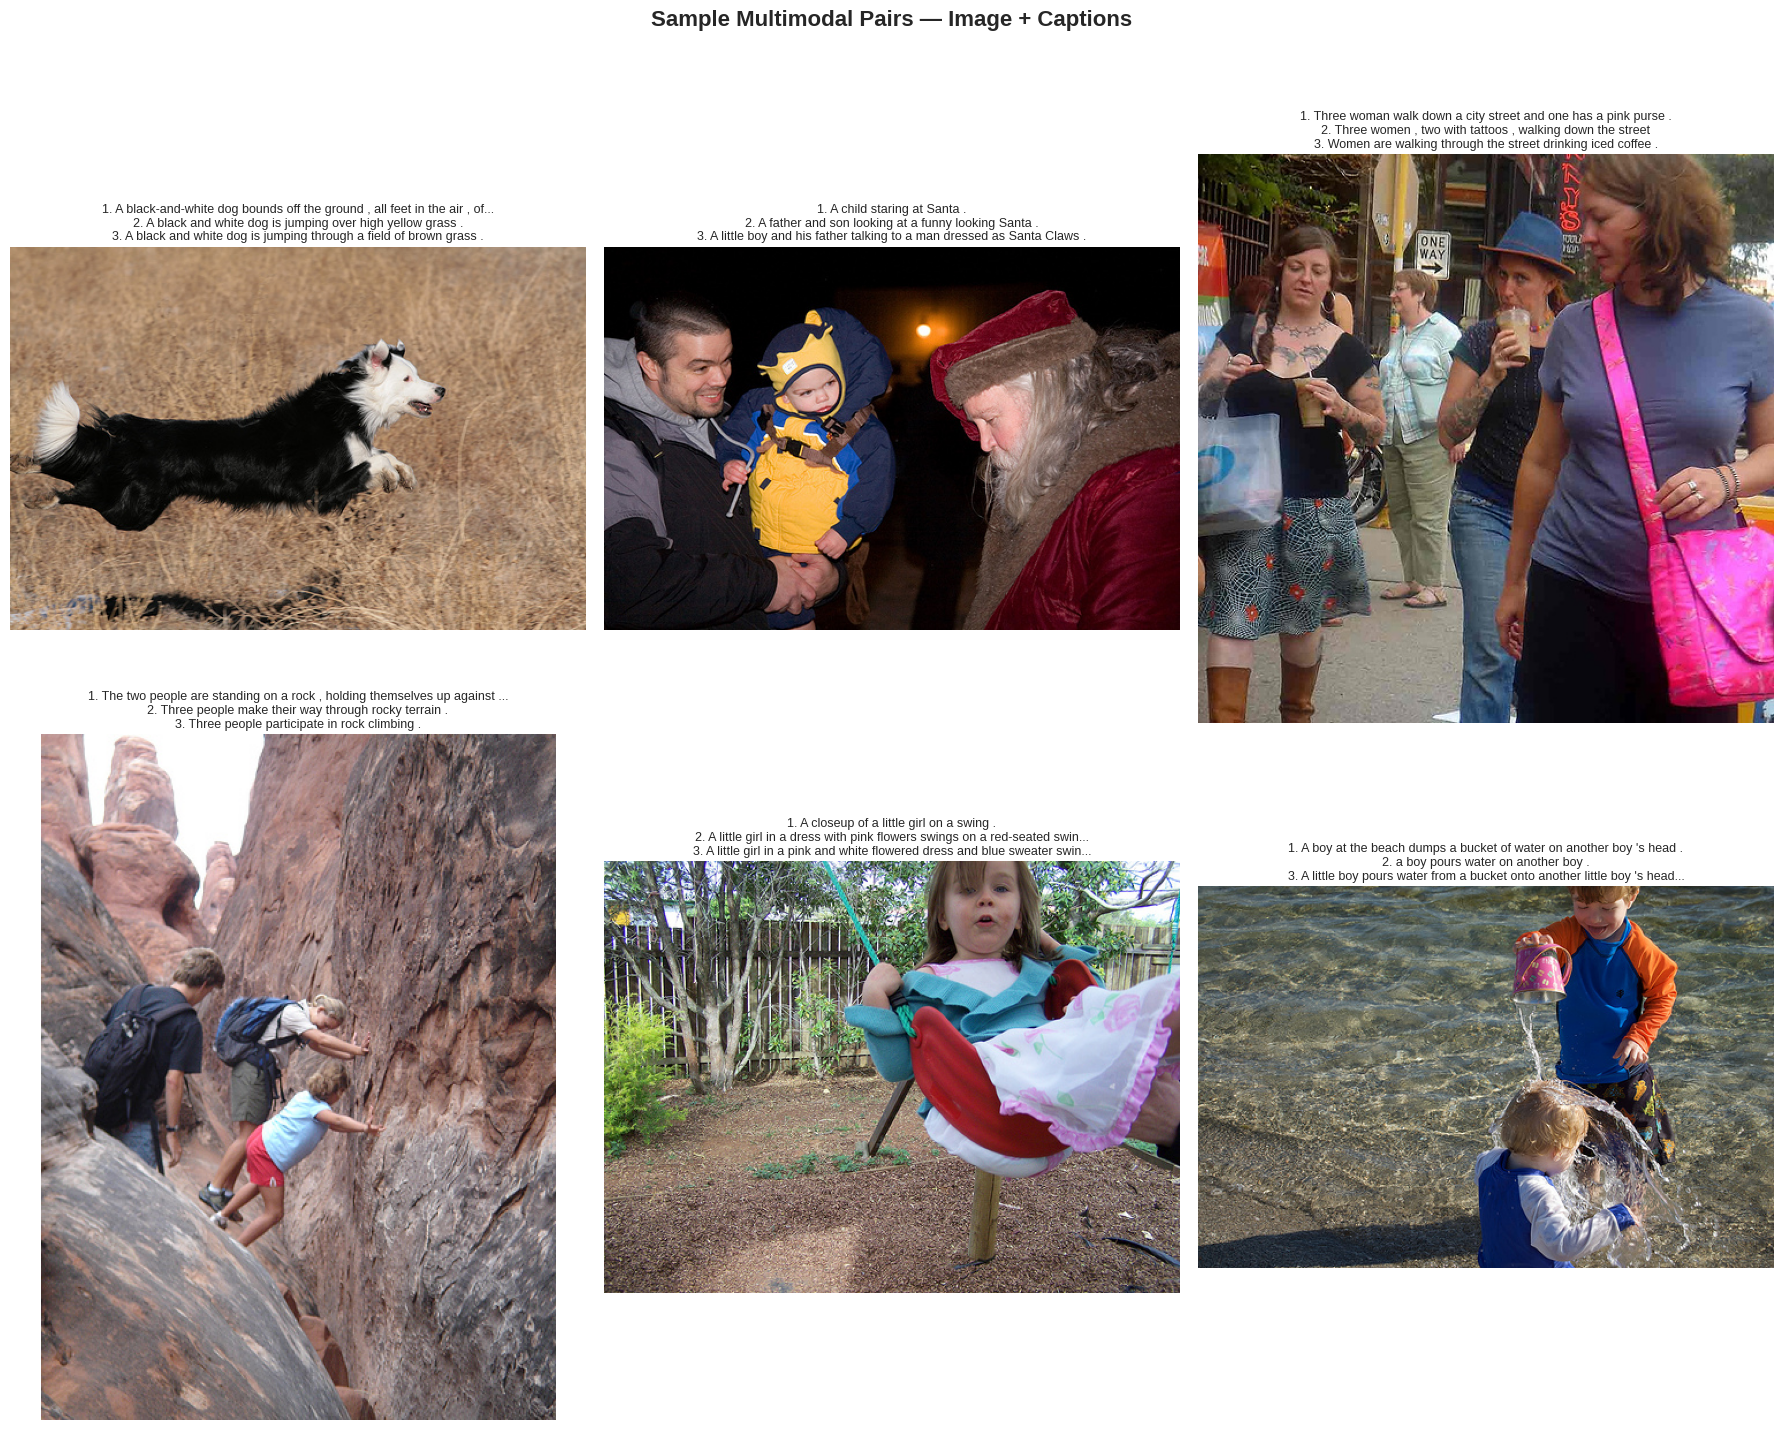

In [10]:
log('\n=== SECTION 8: SAMPLE MULTIMODAL PAIRS ===')

np.random.seed(42)
sample_images = np.random.choice(df['image'].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

sample_pairs = []
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(IMAGES_DIR, img_name)
    try:
        img = Image.open(img_path)
        axes[i].imshow(img)
    except:
        axes[i].text(0.5, 0.5, 'Image not found', ha='center')
    
    caps = df[df['image'] == img_name]['caption'].values
    caption_text = '\n'.join([f'{j+1}. {c[:70]}' + ('...' if len(c)>70 else '')
                              for j, c in enumerate(caps[:3])])
    axes[i].set_title(caption_text, fontsize=9, wrap=True)
    axes[i].axis('off')
    
    sample_pairs.append({'image': img_name, 'captions': caps.tolist()})
    log(f'  {img_name}: {caps[0][:80]}...')

json_data['sample_pairs'] = sample_pairs
save_json()

plt.suptitle('Sample Multimodal Pairs — Image + Captions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_07_sample_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

## 9A. 🏷️ POS Tag Distribution Analysis


=== SECTION 9A: POS TAG DISTRIBUTION ===
⏳ POS tagging captions (this may take ~2 minutes)...
POS Tag Distribution (sampled 10K captions):
  NOUN: 34556 (32.04%)
  DET: 21362 (19.81%)
  ADP: 16501 (15.3%)
  VERB: 12151 (11.27%)
  ADJ: 10166 (9.43%)
  AUX: 3448 (3.2%)
  CCONJ: 2321 (2.15%)
  NUM: 2224 (2.06%)
  PRON: 1983 (1.84%)
  ADV: 1122 (1.04%)
  PROPN: 934 (0.87%)
  SCONJ: 555 (0.51%)
  PART: 471 (0.44%)
  INTJ: 37 (0.03%)
  X: 5 (0.0%)


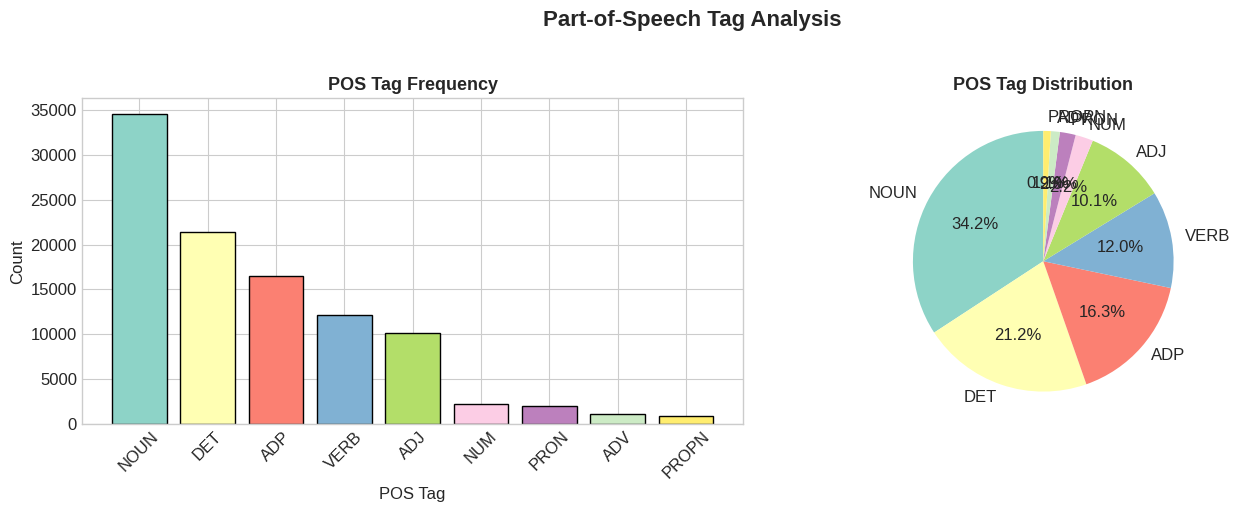

✅ POS analysis complete: 15 tags found


In [11]:
log('\n=== SECTION 9A: POS TAG DISTRIBUTION ===')

# Install spacy model if needed
import subprocess, sys
try:
    import spacy
    try:
        nlp = spacy.load('en_core_web_sm')
    except:
        subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])
        nlp = spacy.load('en_core_web_sm')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'spacy'])
    import spacy
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

print('⏳ POS tagging captions (this may take ~2 minutes)...')

# Sample for speed (full dataset takes too long)
np.random.seed(42)
sample_captions = df['caption'].sample(min(10000, len(df)), random_state=42).values

pos_counter = Counter()
for doc in nlp.pipe(sample_captions, batch_size=500, disable=['ner', 'parser']):
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_counter[token.pos_] += 1

total_tokens = sum(pos_counter.values())
pos_data = []
log('POS Tag Distribution (sampled 10K captions):')
for tag, count in pos_counter.most_common():
    pct = round(count / total_tokens * 100, 2)
    pos_data.append({'tag': tag, 'count': count, 'percentage': pct})
    log(f'  {tag}: {count} ({pct}%)')

json_data.setdefault('textual_modality', {})['pos_distribution'] = pos_data
save_json()

# --- Chart ---
major_pos = [d for d in pos_data if d['tag'] in ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN', 'DET', 'ADP', 'NUM', 'PRON']]
if major_pos:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    tags = [d['tag'] for d in major_pos]
    counts = [d['count'] for d in major_pos]
    pcts = [d['percentage'] for d in major_pos]
    colors = plt.cm.Set3(np.linspace(0, 1, len(tags)))
    
    axes[0].bar(tags, counts, color=colors, edgecolor='black')
    axes[0].set_title('POS Tag Frequency', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('POS Tag')
    axes[0].set_ylabel('Count')
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    
    axes[1].pie(counts, labels=tags, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title('POS Tag Distribution', fontsize=13, fontweight='bold')
    
    plt.suptitle('Part-of-Speech Tag Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('multimodal_08_pos_tags.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'✅ POS analysis complete: {len(pos_data)} tags found')

## 9B. 🔄 Duplicate Captions Detection

In [12]:
log('\n=== SECTION 9B: DUPLICATE CAPTIONS ===')

# Normalize captions for comparison
df['caption_normalized'] = df['caption'].str.lower().str.strip()

# Find captions that appear for multiple different images
caption_image_groups = df.groupby('caption_normalized')['image'].nunique()
duplicated_across_images = caption_image_groups[caption_image_groups > 1]

# Total duplicate instances
dup_captions = df[df['caption_normalized'].isin(duplicated_across_images.index)]
total_duplicates = len(dup_captions)
total_unique = df['caption_normalized'].nunique()
dup_pct = round(total_duplicates / len(df) * 100, 2)

# Exact duplicates (same caption text)
exact_dup_count = df['caption_normalized'].duplicated().sum()

log(f'Total unique captions: {total_unique}')
log(f'Exact duplicate caption rows: {exact_dup_count} ({exact_dup_count/len(df)*100:.2f}%)')
log(f'Captions appearing for multiple images: {len(duplicated_across_images)}')
log(f'Total rows with cross-image duplicates: {total_duplicates} ({dup_pct}%)')

# Top duplicates
top_dups = []
for cap, n_images in duplicated_across_images.sort_values(ascending=False).head(10).items():
    total_occurrences = int((df['caption_normalized'] == cap).sum())
    top_dups.append({'caption': cap, 'n_different_images': int(n_images), 'total_occurrences': total_occurrences})
    log(f'  "{cap[:70]}..." → {n_images} different images, {total_occurrences} total')

json_data.setdefault('data_quality', {})['duplicate_captions'] = {
    'total_unique_captions': int(total_unique),
    'exact_duplicate_rows': int(exact_dup_count),
    'exact_duplicate_pct': round(exact_dup_count / len(df) * 100, 2),
    'cross_image_duplicate_captions': int(len(duplicated_across_images)),
    'cross_image_duplicate_rows': total_duplicates,
    'cross_image_duplicate_pct': dup_pct,
    'top_duplicates': top_dups
}
save_json()
print(f'✅ Duplicate analysis complete')


=== SECTION 9B: DUPLICATE CAPTIONS ===
Total unique captions: 40170
Exact duplicate caption rows: 285 (0.70%)
Captions appearing for multiple images: 199
Total rows with cross-image duplicates: 473 (1.17%)
  "a dog runs through the grass ...." → 7 different images, 7 total
  "two dogs playing in the snow ...." → 7 different images, 7 total
  "a person on a bmx bike ...." → 6 different images, 6 total
  "two dogs play together ...." → 6 different images, 6 total
  "two dogs play in the grass ...." → 6 different images, 6 total
  "a dog runs through the snow ...." → 5 different images, 5 total
  "a dog plays in the snow ...." → 5 different images, 5 total
  "a dog runs across the grass ...." → 5 different images, 5 total
  "two dogs run through a field ...." → 5 different images, 5 total
  "a dog swimming with a stick in its mouth ...." → 5 different images, 6 total
✅ Duplicate analysis complete


## 9C. 📏 Outlier Captions Detection

In [13]:
log('\n=== SECTION 9C: OUTLIER CAPTIONS ===')

wc = df['caption_word_count']
Q1 = float(wc.quantile(0.25))
Q3 = float(wc.quantile(0.75))
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_long = df[wc > upper_bound]
outliers_short = df[wc < lower_bound]
all_outliers = pd.concat([outliers_short, outliers_long])

log(f'IQR Method: Q1={Q1}, Q3={Q3}, IQR={IQR}')
log(f'Valid range: [{lower_bound:.1f}, {upper_bound:.1f}] words')
log(f'Outliers (too short): {len(outliers_short)}')
log(f'Outliers (too long): {len(outliers_long)}')
log(f'Total outliers: {len(all_outliers)} ({len(all_outliers)/len(df)*100:.3f}%)')

# List outlier captions
outlier_list = []
for _, row in all_outliers.head(20).iterrows():
    outlier_list.append({
        'image': row['image'],
        'caption': row['caption'][:100],
        'word_count': int(row['caption_word_count']),
        'type': 'too_short' if row['caption_word_count'] < lower_bound else 'too_long'
    })
    log(f'  [{row["caption_word_count"]} words] {row["caption"][:80]}...')

json_data.setdefault('data_quality', {})['outlier_captions'] = {
    'method': 'IQR (1.5x)',
    'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
    'lower_bound': round(lower_bound, 1),
    'upper_bound': round(upper_bound, 1),
    'outliers_short': len(outliers_short),
    'outliers_long': len(outliers_long),
    'total_outliers': len(all_outliers),
    'outlier_pct': round(len(all_outliers) / len(df) * 100, 3),
    'sample_outliers': outlier_list
}
save_json()
print(f'✅ Outlier detection complete: {len(all_outliers)} outliers found')


=== SECTION 9C: OUTLIER CAPTIONS ===
IQR Method: Q1=9.0, Q3=14.0, IQR=5.0
Valid range: [1.5, 21.5] words
Outliers (too short): 2
Outliers (too long): 704
Total outliers: 706 (1.745%)
  [1 words] A...
  [1 words] a...
  [23 words] A couple and an infant , being held by the male , sitting next to a pond with a ...
  [24 words] A man is holding the hand of a woman up to his mouth in front of some buildings ...
  [23 words] A man lies on a mat in a parking lot between a brown SUV and a yellow pickup wit...
  [23 words] A boy in blue swimming trunks slides down a yellow slide into a wading pool with...
  [25 words] A man in water throwing a little boy up in the air and waiting for him to come d...
  [28 words] The girl in the salmon colored bikini is standing next to two young people ; one...
  [22 words] A woman dressed in a blue jacket and blue jeans rides a brown horse near a froze...
  [23 words] A woman wearing a blue dress is drawing a picture of a boy and a girl on the sid...
  [22 

## 9D. ⚖️ Gender Bias Analysis


=== SECTION 9D: GENDER BIAS ANALYSIS ===
Male-gendered words total: 16035
Female-gendered words total: 9923
Gender bias ratio (M/F): 1.62x

Top male words: [('man', 7274), ('boy', 3581), ('his', 2357), ('men', 1121), ('boys', 666)]
Top female words: [('woman', 3402), ('girl', 3328), ('her', 1178), ('girls', 844), ('women', 652)]


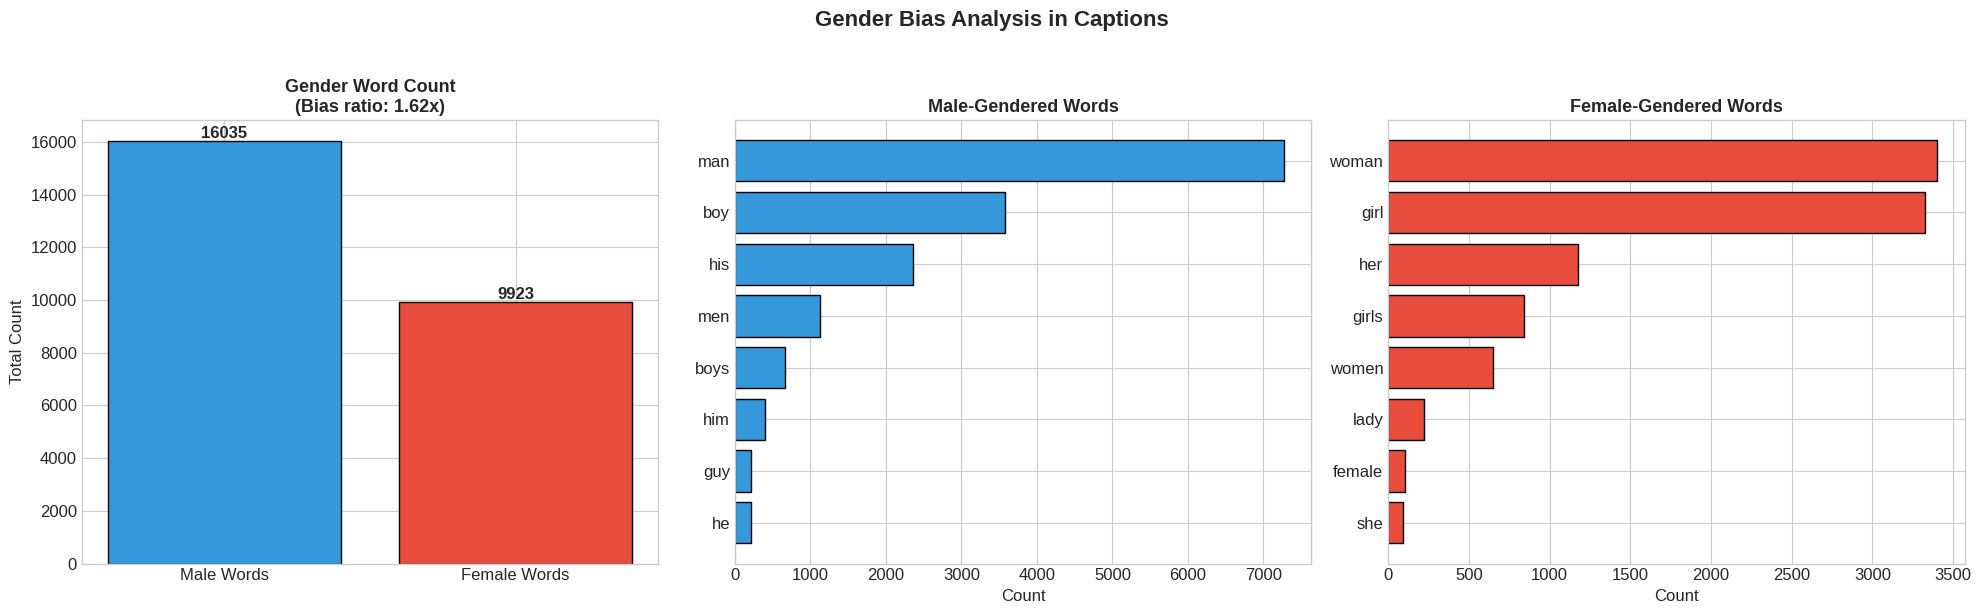

✅ Gender bias analysis complete: ratio = 1.62x (male/female)


In [14]:
log('\n=== SECTION 9D: GENDER BIAS ANALYSIS ===')

male_words = ['man', 'men', 'boy', 'boys', 'male', 'he', 'his', 'him',
              'himself', 'father', 'dad', 'son', 'brother', 'guy', 'gentleman']
female_words = ['woman', 'women', 'girl', 'girls', 'female', 'she', 'her',
                'herself', 'mother', 'mom', 'daughter', 'sister', 'lady']

all_text_lower = ' '.join(df['caption'].str.lower())

male_freq = []
male_total = 0
for word in male_words:
    count = len(re.findall(r'\b' + word + r'\b', all_text_lower))
    if count > 0:
        male_freq.append({'word': word, 'count': count})
    male_total += count

female_freq = []
female_total = 0
for word in female_words:
    count = len(re.findall(r'\b' + word + r'\b', all_text_lower))
    if count > 0:
        female_freq.append({'word': word, 'count': count})
    female_total += count

male_freq.sort(key=lambda x: x['count'], reverse=True)
female_freq.sort(key=lambda x: x['count'], reverse=True)

bias_ratio = round(male_total / max(female_total, 1), 2)

log(f'Male-gendered words total: {male_total}')
log(f'Female-gendered words total: {female_total}')
log(f'Gender bias ratio (M/F): {bias_ratio}x')
log(f'\nTop male words: {[(d["word"], d["count"]) for d in male_freq[:5]]}')
log(f'Top female words: {[(d["word"], d["count"]) for d in female_freq[:5]]}')

json_data['bias_analysis'] = {
    'gender_bias': {
        'male_words_total': male_total,
        'female_words_total': female_total,
        'bias_ratio': bias_ratio,
        'male_word_freq': male_freq,
        'female_word_freq': female_freq
    }
}
save_json()

# --- Chart ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Overall comparison
axes[0].bar(['Male Words', 'Female Words'], [male_total, female_total],
            color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title(f'Gender Word Count\n(Bias ratio: {bias_ratio}x)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Count')
for i, v in enumerate([male_total, female_total]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Male word breakdown
m_words = [d['word'] for d in male_freq[:8]]
m_counts = [d['count'] for d in male_freq[:8]]
axes[1].barh(range(len(m_words)), m_counts, color='#3498db', edgecolor='black')
axes[1].set_yticks(range(len(m_words)))
axes[1].set_yticklabels(m_words)
axes[1].set_title('Male-Gendered Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

# Female word breakdown
f_words = [d['word'] for d in female_freq[:8]]
f_counts = [d['count'] for d in female_freq[:8]]
axes[2].barh(range(len(f_words)), f_counts, color='#e74c3c', edgecolor='black')
axes[2].set_yticks(range(len(f_words)))
axes[2].set_yticklabels(f_words)
axes[2].set_title('Female-Gendered Words', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].invert_yaxis()

plt.suptitle('Gender Bias Analysis in Captions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multimodal_09_gender_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Gender bias analysis complete: ratio = {bias_ratio}x (male/female)')

## 10. 💡 Key Insights & Preprocessing Suggestions (Updated)

In [15]:
log('\n=== SECTION 10: KEY INSIGHTS (UPDATED) ===')

insights = {
    'dataset_characteristics': [
        f'{n_unique_images} unique images × 5 captions = {n_total_pairs} multimodal pairs',
        f'2 modalities: Image (JPEG) + Text (English caption)',
        f'{len(complete_pairs)} complete pairs ({len(complete_pairs)/n_unique_images*100:.1f}%)',
        f'{corrupted_count} corrupted images detected (out of {len(check_files)} sampled)',
        f'Image sizes non-uniform: mainly 500×333 or 333×500 (landscape/portrait)',
        f'Captions avg {text_stats["word_count"]["mean"]} words, vocab size {vocab_size}',
        f'Stopword ratio: {stopword_ratio:.1f}%',
        f'61.1% of captions start with "A" — dominant descriptive pattern',
        f'Most described subjects: dog, man, woman, boy, girl',
        f'Inter-annotator Jaccard similarity: {similarity_mean:.3f} (moderate agreement)',
        f'Warm-toned images: R={np.mean(avg_r):.1f}, G={np.mean(avg_g):.1f}, B={np.mean(avg_b):.1f}',
        f'POS distribution: NOUNs dominate captions (typical for descriptive text)',
        f'Gender bias ratio: {bias_ratio}x (more male-gendered words than female)',
        f'Duplicate captions across images: {len(duplicated_across_images)} unique captions shared',
        f'Outlier captions (IQR): {len(all_outliers)} ({len(all_outliers)/len(df)*100:.3f}%)'
    ],
    'unimodal_preprocessing': [
        'IMAGE: Resize all images to uniform resolution (e.g., 224×224 for CNN, 384×384 for ViT)',
        'IMAGE: Normalize pixel values to [0,1] or standardize with ImageNet mean/std',
        'IMAGE: Apply data augmentation (random crop, flip, color jitter) for training',
        'TEXT: Lowercase + remove punctuation',
        'TEXT: Tokenize using WordPiece/BPE for transformer models',
        'TEXT: Pad/truncate captions to fixed max length',
        'TEXT: Build vocabulary with frequency threshold (e.g., min_freq=5)',
        'TEXT: Consider removing outlier captions (too short/too long)'
    ],
    'crossmodal_preprocessing': [
        'Drop samples with missing modality (text-only or image-only)',
        'Drop corrupted images or replace with placeholder',
        'Align image-caption pairs: ensure each image maps to exactly 5 captions',
        'Handle duplicate captions: decide whether to keep or deduplicate',
        'Consider gender bias when evaluating model outputs',
        'For evaluation: use BLEU/CIDEr/METEOR scores with all 5 reference captions',
        f'Dataset is small (8K images) — consider pre-training on larger datasets (COCO 330K) then fine-tuning'
    ]
}

for section, items in insights.items():
    log(f'\n  {section.upper()}:')
    for item in items:
        log(f'    • {item}')

json_data['insights'] = insights
save_json()

log(f'\n{"=" * 70}')
log(f'Stats exported to: {LOG_FILE}')
log(f'JSON data exported to: {JSON_FILE}')
log(f'{"=" * 70}')

print(f'\n✅ All stats saved to {LOG_FILE}')
print(f'✅ JSON data saved to {JSON_FILE}')
print(f'✅ All figures saved as PNG')


=== SECTION 10: KEY INSIGHTS (UPDATED) ===

  DATASET_CHARACTERISTICS:
    • 8091 unique images × 5 captions = 40455 multimodal pairs
    • 2 modalities: Image (JPEG) + Text (English caption)
    • 8091 complete pairs (100.0%)
    • 0 corrupted images detected (out of 2000 sampled)
    • Image sizes non-uniform: mainly 500×333 or 333×500 (landscape/portrait)
    • Captions avg 11.8 words, vocab size 8274
    • Stopword ratio: 42.4%
    • 61.1% of captions start with "A" — dominant descriptive pattern
    • Most described subjects: dog, man, woman, boy, girl
    • Inter-annotator Jaccard similarity: 0.278 (moderate agreement)
    • Warm-toned images: R=117.0, G=113.8, B=103.2
    • POS distribution: NOUNs dominate captions (typical for descriptive text)
    • Gender bias ratio: 1.62x (more male-gendered words than female)
    • Duplicate captions across images: 199 unique captions shared
    • Outlier captions (IQR): 706 (1.745%)

  UNIMODAL_PREPROCESSING:
    • IMAGE: Resize all image